# Combinatorial CoWork 2026 — Notebook 01: Presentations to encodings

Audience:
- Participants who want to see the same mathematical motif appear through several source-object families.

Learning goals:
- Compare `SyntheticBoxFringe`, `PLFringe`, and `Flange` as source presentations.
- Confirm that `encode(...)` is the canonical workflow entrypoint regardless of synthetic provenance.
- Inspect the resulting encodings through summaries, accessors, and region/rank visuals.


In [29]:
NOTEBOOK_STEM = "01_presentations_to_encodings"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

if !isdefined(Main, :TamerOp)
    try
        @eval Main using TamerOp
    catch
        Base.include(Main, joinpath(_TO_ROOT, "src", "TamerOp.jl"))
    end
end

TO = Main.TamerOp



Main.TamerOp

## 1. Build four tiny source objects with the same broad geometric theme

We deliberately reuse interval/rectangle-style data so the only moving part is the source-object family, not the underlying mathematical picture.


In [30]:
SD = TO.SyntheticData

box_diag = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0]), ([1.5, 0.25], [2.5, 1.25])]
)

box_coupled = SD.staircase_box_fringe(
    bars=[([0.0, 0.0], [1.75, 1.0]), ([0.75, 0.5], [2.5, 2.0]), ([1.5, 1.0], [3.5, 2.75])]
)

pl_diag = SD.pl_box_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0]), ([1.0, 0.5], [2.25, 1.75])]
)

flange_rect = SD.orthant_bar_flange(
    bars=[([0, 0], [2, 2]), ([1, 1], [3, 3])],
)

(; box_diag=TO.describe(box_diag),
   box_coupled=TO.describe(box_coupled),
   pl_diag=TO.describe(pl_diag),
   flange_rect=TO.describe(flange_rect))


(box_diag = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, matrix_size = (2, 2), field = Main.TamerOp.CoreModules.CoeffFields.QQField()), box_coupled = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 3, ndownsets = 3, matrix_size = (3, 3), field = Main.TamerOp.CoreModules.CoeffFields.QQField()), pl_diag = (kind = :pl_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, field = Main.TamerOp.CoreModules.CoeffFields.QQField(), matrix_size = (2, 2)), flange_rect = (kind = :flange, ambient_dim = 2, field = "Main.TamerOp.CoreModules.CoeffFields.QQField", nflats = 2, ninjectives = 2, matrix_size = (2, 2)))

## 2. Encode each source object through the same workflow surface

The output objects differ only because the source geometry differs, not because the workflow surface changed.


In [31]:
enc_box_diag = TO.encode(box_diag)
enc_box_coupled = TO.encode(box_coupled)
enc_pl_diag = TO.encode(pl_diag)
enc_flange_rect = TO.encode(flange_rect)

(; box_diag=TO.describe(enc_box_diag),
   box_coupled=TO.describe(enc_box_coupled),
   pl_diag=TO.describe(enc_pl_diag),
   flange_rect=TO.describe(enc_flange_rect))


(box_diag = (kind = :encoding_result, poset_type = Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = Main.TamerOp.Modules.PModule{Rational{BigInt}, Main.TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = Main.TamerOp.EncodingCore.CompiledEncoding{Main.TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, Main.TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 1, 0, 0, 1, 0]), box_coupled = (kind = :encoding_result, poset_type = Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = Main.TamerOp.Modules.PModule{Rational{BigInt}, Main.TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = Main.TamerOp.Encodi

## 3. Visualize the four encodings directly

At this point we have four `EncodingResult`s. Before asking for new invariants, it is worth seeing the encoded region geometry itself. Each cell below renders the encoding regions for one source family.


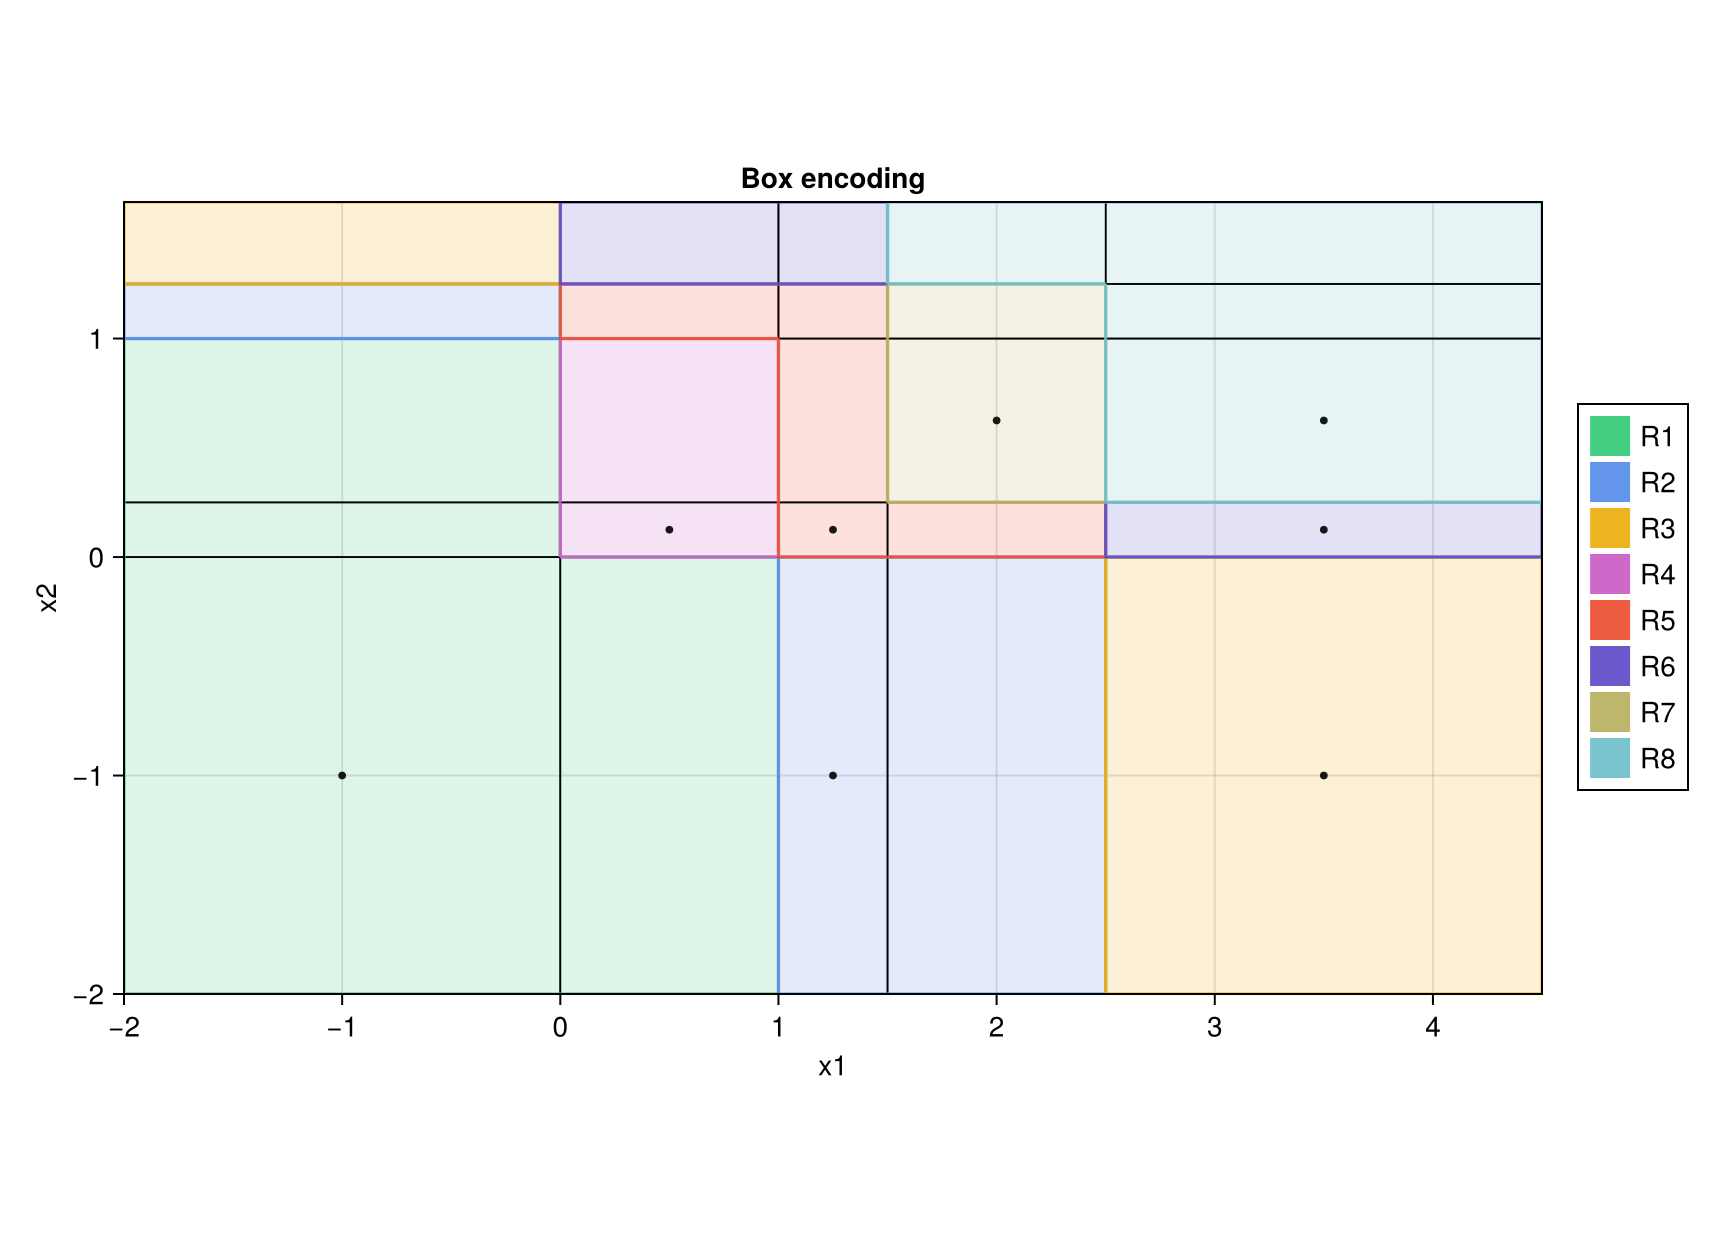

In [36]:
TO.visualize(TO.encoding_map(enc_box_diag); kind=:regions, backend=:cairomakie)


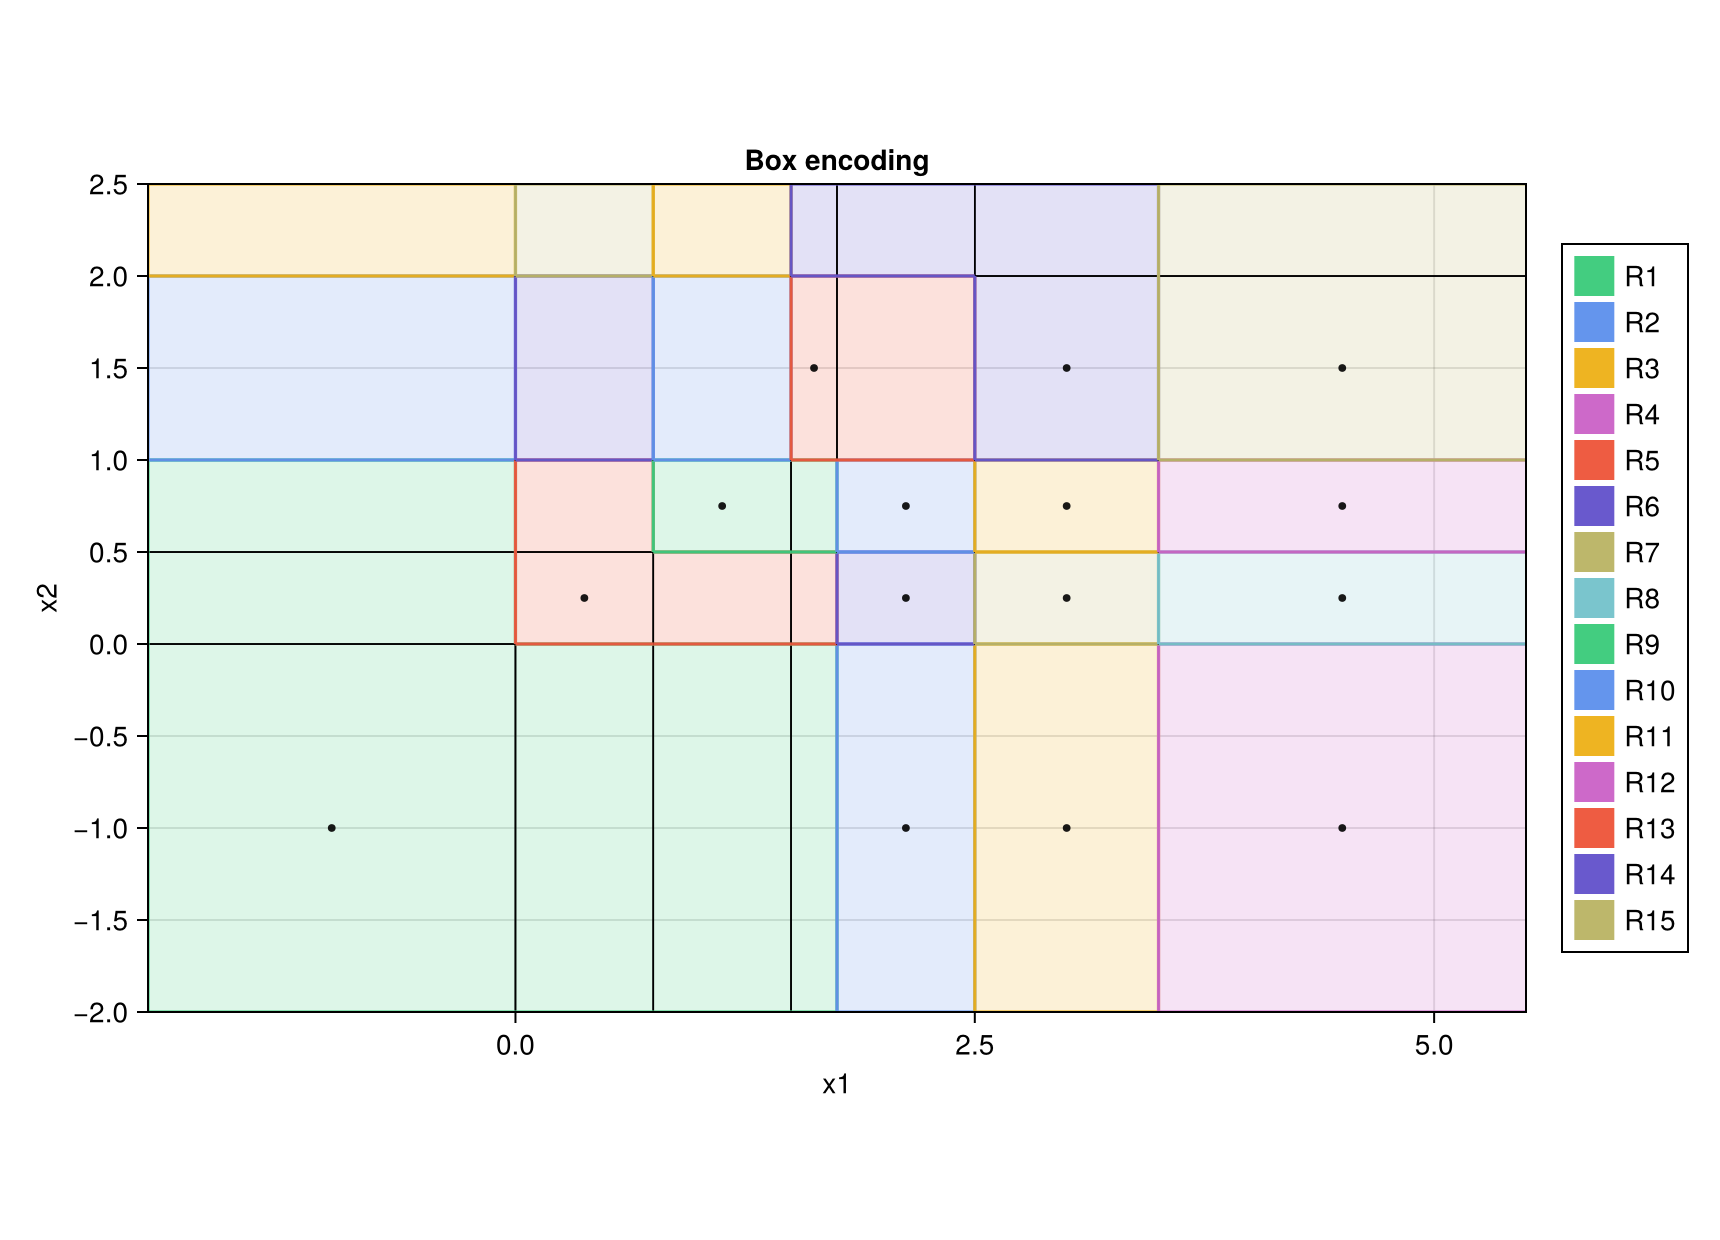

In [37]:
TO.visualize(TO.encoding_map(enc_box_coupled); kind=:regions, backend=:cairomakie)


In [38]:
TO.visualize(TO.encoding_map(enc_pl_diag); kind=:regions, backend=:cairomakie)


ArgumentError: ArgumentError: check_visual_request: no visualization kinds are registered for CompiledEncoding. kind=regions is unsupported for CompiledEncoding; supported kinds are ().

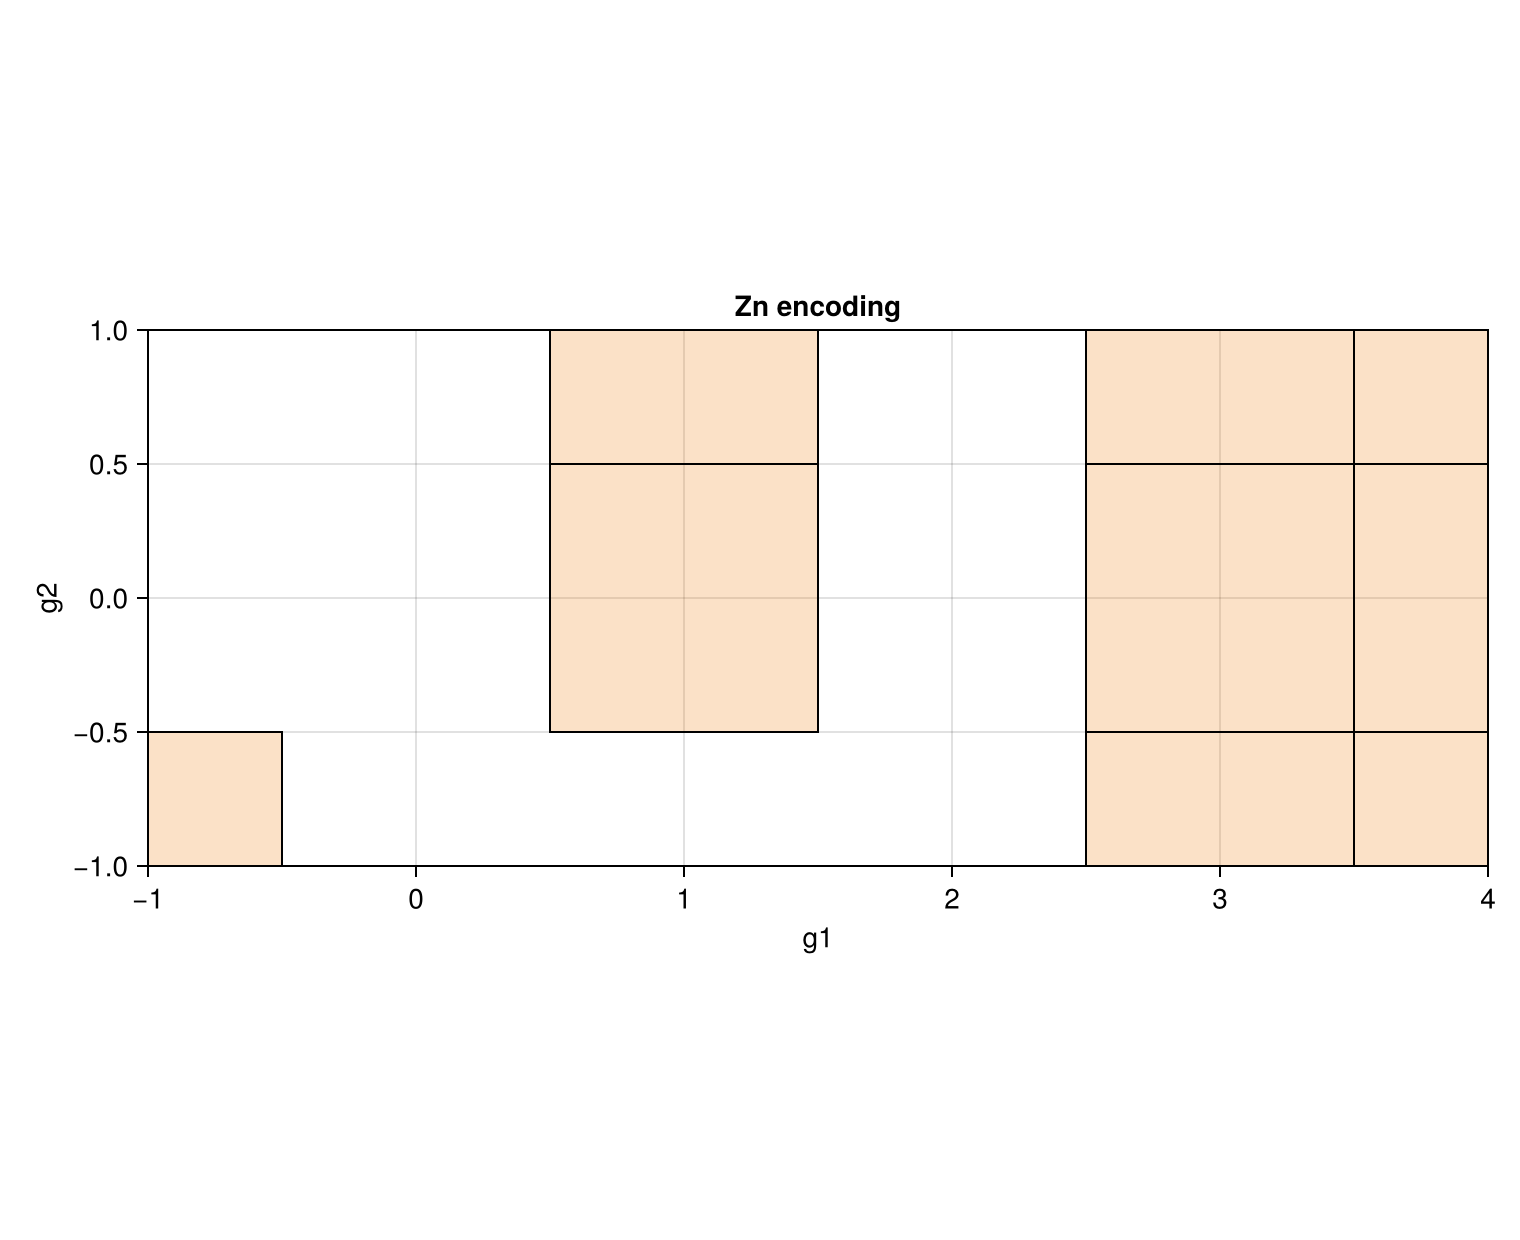

In [39]:
TO.visualize(TO.encoding_map(enc_flange_rect); kind=:regions, backend=:cairomakie)


## 4. Inspect the encoded geometry and one invariant

For a talk, this is the right point to emphasize that the encoded object is now the stable computational handle. We ask for axes, available visuals, and a rank invariant without caring which source family we started from. We also build the visual summary explicitly rather than hiding it behind a notebook helper.


In [40]:
rank_coupled = TO.rank_invariant(enc_box_coupled)

box_regions_spec = TO.Visualization.visual_spec(TO.encoding_map(enc_box_diag); kind=:regions)
coupled_rank_spec = TO.Visualization.visual_spec(rank_coupled; kind=:rank_heatmap)

(; box_axes=TO.encoding_axes(TO.encoding_map(enc_box_diag)),
   coupled_rank_summary=TO.describe(rank_coupled),
   box_regions_summary=TO.Visualization.visual_summary(box_regions_spec),
   coupled_rank_heatmap_summary=TO.Visualization.visual_summary(coupled_rank_spec))


(box_axes = ([0.0, 1.0, 1.5, 2.5], [0.0, 0.25, 1.0, 1.25]), coupled_rank_summary = (kind = :rank_invariant, nentries = 10, nnonzero = 10, store_zeros = false, nvertices = 15, poset_type = Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}), box_regions_summary = (kind = :visualization_spec, visual_kind = :regions, title = "Box encoding", subtitle = "", nlayers = 17, npanels = 0, layer_types = (:RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :PointLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-2.0, 4.5), ylimits = (-2.0, 1.625), zlabel = "z", zlimits = nothing, aspect = :data, xticks = nothing, yticks = nothing), metadata = (object = :pl_boxes, nregions = 8, ncells = 25, query_count = 0, figure_size = (860, 620), legend_position = :right), legend_visible = true, interaction = (hover = true, labels = false, clicks = f

Now render every visualization that the coupled rank object says it supports. This is a good example of the notebook pattern:

- ask the object what views it has with `available_visuals(...)`,
- then render those views explicitly.


visualizing kind = rank_heatmap
visualizing kind = rank_rectangles


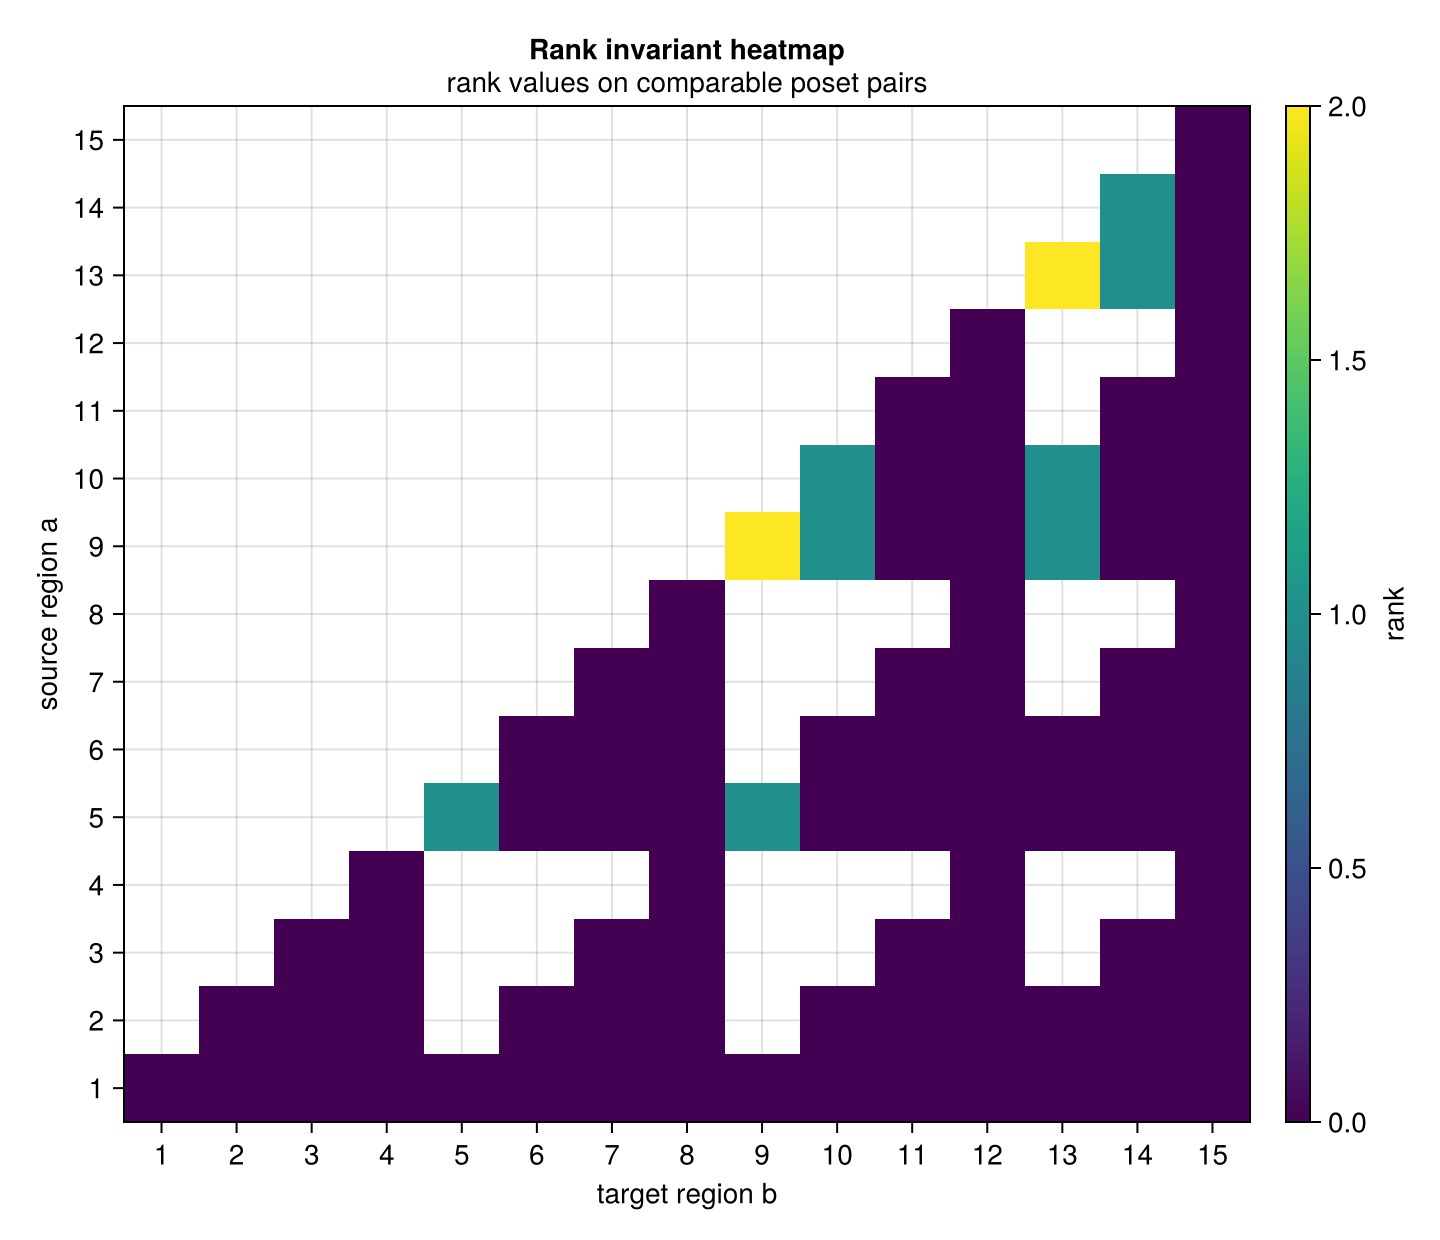

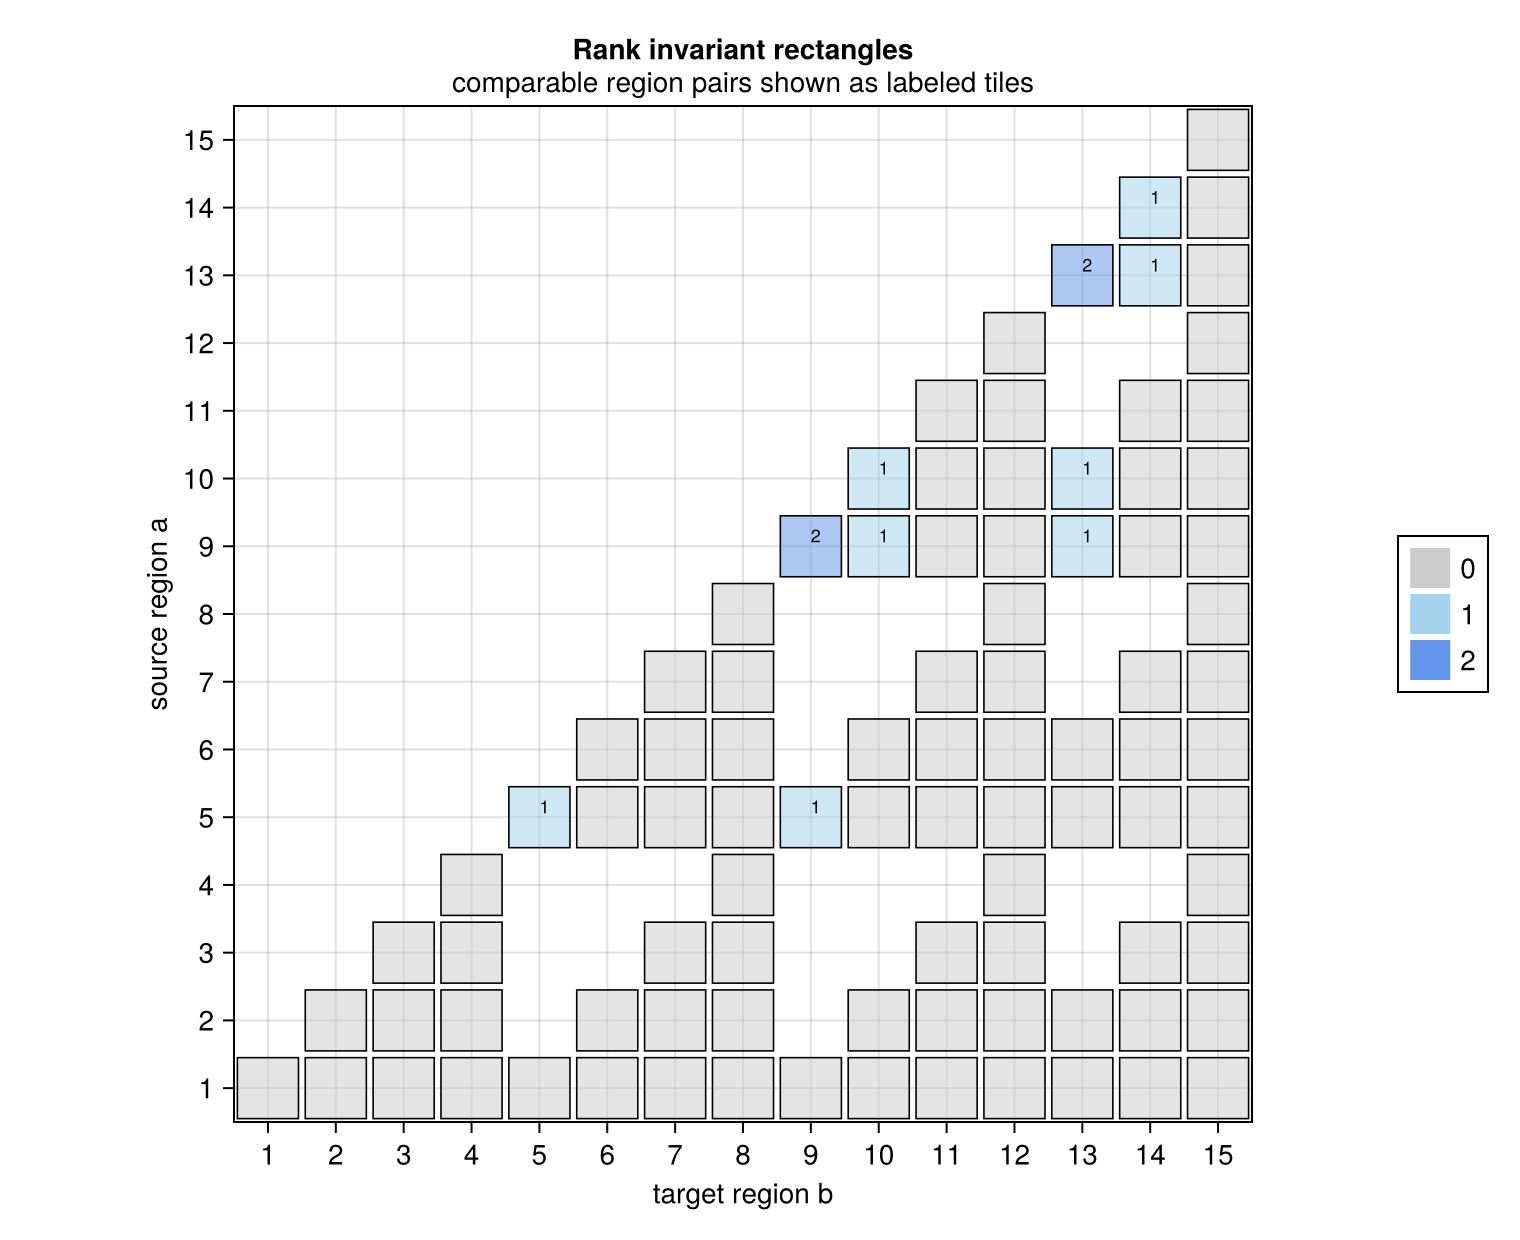

In [41]:
coupled_rank_visual_kinds = TO.available_visuals(rank_coupled)

for kind in coupled_rank_visual_kinds
    println("visualizing kind = ", kind)
    try
        display(TO.visualize(rank_coupled; kind=kind))
    catch err
        display((; kind,
                  visualization_error=sprint(showerror, err),
                  note="If no renderer is active, use the visual summaries above or the export cell below."))
    end
end


## 5. Export two visuals to disk

This is the canonical export path. We write HTML visual-spec artifacts so the cell stays deterministic on participant laptops while still teaching `save_visuals(...)` directly.


In [42]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)

exports = TO.save_visuals(
    outdir,
    [
        (; stem="box_diag_regions", obj=TO.encoding_map(enc_box_diag), kind=:regions),
        (; stem="box_coupled_rank_heatmap", obj=rank_coupled, kind=:rank_heatmap),
    ];
    format=:html,
    backend=:cairomakie,
)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 2 entries:
  "box_coupled_rank_heatmap" => "/home/eriknovak/Documents/duke_fall_2025/tamer…
  "box_diag_regions"         => "/home/eriknovak/Documents/duke_fall_2025/tamer…

## Try this next

Replace `box_diag` with `SD.staircase_box_fringe(...)` or change the `bars=` data for `pl_diag`. Then rerun the encoding cell and compare the summaries.


In [43]:
box_variant = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.25, 1.0]), ([1.0, 0.0], [2.5, 1.75])]
)
enc_variant = TO.encode(box_variant)

(; variant_source=SD.box_fringe_summary(box_variant),
   variant_encoding=TO.describe(enc_variant),
   variant_visuals=TO.available_visuals(TO.encoding_map(enc_variant)))


(variant_source = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, matrix_size = (2, 2), field = Main.TamerOp.CoreModules.CoeffFields.QQField()), variant_encoding = (kind = :encoding_result, poset_type = Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = Main.TamerOp.Modules.PModule{Rational{BigInt}, Main.TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = Main.TamerOp.EncodingCore.CompiledEncoding{Main.TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, Main.TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, Main.TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 1, 2, 1, 0, 0, 0]), variant_visuals = (:regions, :region_labels, :query_overlay))